# Week 4 Day 4

# Model Tuning, Regularization & Reproducible Pipelines
## Scenario
Turn your best candidate models into well-tuned, robust pipelines. You'll run controlled hyperparameter searches, inspect learning curves to diagnose bias/variance, apply regularization and calibration, and produce a reproducible, saved pipeline.

### Task 1: Build Fully Reproducible Pipelines
- Use sklearn Pipeline (or imblearn Pipeline if resampling later) to combine preprocessing + feature transforms + estimator.
- Control all randomness — set random_state everywhere. Document library versions used.
- Add a short README cell explaining how to re-run training and reproduce results.

### Task 2: Hyperparameter Search (Randomized/Grid)
For your top models, run RandomizedSearchCV or GridSearchCV with sensible ranges:
- Logistic Regression: penalty (l1/l2), C (inverse regularization)
- Random Forest: n_estimators, max_depth, min_samples_leaf, max_features
- Gradient Boosting: learning_rate, max_iter/n_estimators, max_depth, l2_regularization
- Use StratifiedKFold inside the search, optimize your primary metric, and run with n_jobs=-1.
- Keep the search budget realistic — e.g., n_iter=50–100 for RandomizedSearch.

### Task 3: Diagnose Overfitting / Underfitting
- For at least one model, plot learning curves (train vs. validation score) across training set sizes to spot bias vs. variance.
- Logistic Regression: show effect of C on train/validation performance.
- Tree-based models: show effect of max_depth or min_samples_leaf.
- Based on the curves, state concrete fixes (more data? stronger regularization? lower depth?).


### Task 4: Probability Calibration & Threshold Selection
- Evaluate probability calibration using calibration plots + Brier score. If needed, apply CalibratedClassifierCV (isotonic or sigmoid).
- Tune the classification threshold to optimize your chosen business metric (e.g., maximize F1, or hit a target precision). Show how different thresholds change the confusion matrix and business KPIs.

### Task 5: Final Evaluation & Save Artifact
- Evaluate the final tuned + calibrated pipeline on the untouched hold-out test set. Report a full metrics table + curves.
- Save the final pipeline (preprocessing + model) using joblib/pickle, with a short "how-to-infer" snippet.
- Summarize: hyperparameter choices, best parameters, final test metrics, and a short note on expected production behavior.


### Deliverable
- A notebook
- A saved model artifact (.pkl or .joblib) with the full pipeline
- A 1–2 page tuning report summarizing search, diagnostics, and final performance



### Import Libraries 

In [1]:
# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset
from sklearn.datasets import fetch_openml

# Train/Test Split
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# average_precision_score computes PR_AUC

# For Baseline Models
from sklearn.dummy import DummyClassifier

# Notebook Settings
pd.set_option("display.max_columns", None) # display all cols

sns.set_style("whitegrid") # clean white bkgrd for plots

## Problem Definition

### Business Objective

The objective is to identify individuals who are likely to earn >50K per year. A company could use this prediction to target premium products or marketing campaigns toward higher-income customers while minimizing unnecessary outreach.

### Target Variable

- Positive Class (1): Income >50K
- Negative Class (0): Income ≤50K

### Primary Evaluation Metric

Precision is selected as the primary evaluation metric because contacting individuals incurs cost. A higher precision means that a larger proportion of contacted individuals actually belong to the high-income group, reducing wasted marketing resources.

Although recall is also important, maximizing precision is more appropriate for this business scenario where false positives are more costly than missing some potential customers.

### Explanation for Non-Technical Stakeholders
We are building a model to help the marketing team identify customers who are more likely to earn over $50,000 per year. This allows the company to focus promotional campaigns on people who are more likely to respond, making better use of the marketing budget. To reduce unnecessary outreach, we prioritize making reliable positive predictions rather than contacting as many people as possible.


### Load Dataset

In [2]:
adult = fetch_openml(
    name="adult",
    version=2,
    as_frame=True
)

# version 2 is selected to make the results reproducible
# as_frame is used to get data in the form of Pandas DataFrame

df = adult.frame.copy()

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


### Preview Column Names

In [3]:
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'class'],
      dtype='str')

### Check Missing Values

In [4]:
# The Adult dataset stores missing values as "?" as per given task details
# Check for missing values

missing_values = df.isna().sum()

display(
    missing_values[missing_values > 0].to_frame("Missing Values")
)

,Missing Values
workclass,2799
occupation,2809
native-country,857


### Missing Value Inspection

The Adult dataset obtained from `fetch_openml()` already represents missing values as `NaN` instead of the original `"?"` symbols found in the raw UCI dataset. Missing values were identified in `workclass`, `occupation`, and `native-country`.

In [5]:
# Check for duplicate rows
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 52


In [6]:
if duplicate_count > 0:
    display(df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10))

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4152,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
40948,17,Private,153021,12th,8,Never-married,Sales,Own-child,White,Female,0,0,20,United-States,<=50K
3900,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
15960,18,Self-emp-inc,378036,12th,8,Never-married,Farming-fishing,Own-child,White,Male,0,0,10,United-States,<=50K
33954,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
34979,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
1668,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
19399,19,Private,130431,5th-6th,3,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,36,Mexico,<=50K
23271,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
37599,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K


In [7]:
# Remove exact duplicate rows before splitting
before = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Duplicates removed: {before - after}")

Rows before: 48842
Rows after:  48790
Duplicates removed: 52


### Convert Target to Binary

In [8]:
# first, see existing lables
df["class"].value_counts()

class
<=50K    37109
>50K     11681
Name: count, dtype: int64

In [9]:
# convert them to binary
df["class"] = (
    df["class"].map({
    "<=50K": 0,
    ">50K": 1
})
.astype(int)
)

df["class"].value_counts()

class
0    37109
1    11681
Name: count, dtype: int64

# Create Reproducible Data Splits

To evaluate a machine learning model fairly, the dataset is divided into separate subsets. The training set is used to learn patterns from the data, while the hold-out test set is kept completely unseen until the final evaluation. This ensures that the reported performance reflects how well the model generalizes to new, unseen data.

### Separate Features and Target

In [10]:
# Features (Independent Variables)
X = df.drop(columns="class")

# Target (Dependent Variable)
y = df["class"]

### Create Appropriate Data Splits

In [11]:
# Step 1: Create the 20% hold-out test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# test_size is used to create a test or hold_out split, here 20 % of the data-> 0.20
# we have used stratified sampling and therefore, startify= y for fair evaluation across test and train splits
# we fixed a random state using random_state so that everyone gets the same split everytime thus making this notebook reproducible

# Step 2: Split the remaining 80% into 70% train and 10% development
X_train, X_dev, y_train, y_dev = train_test_split(
    X_train,
    y_train,
    test_size=0.125,
    stratify=y_train,
    random_state=42
)

### Verify Split Sizes

In [12]:
print("Dataset Split Sizes")
print("-" * 30)

print(f"Training Set      : {X_train.shape[0]} samples")
print(f"Development Set   : {X_dev.shape[0]} samples")
print(f"Hold-Out Test Set : {X_test.shape[0]} samples")

Dataset Split Sizes
------------------------------
Training Set      : 34153 samples
Development Set   : 4879 samples
Hold-Out Test Set : 9758 samples


### Verify Stratification

In [13]:
train_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

dev_distribution = (
    y_dev
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

test_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

comparison = pd.DataFrame({
    "Training (%)": train_distribution.round(2),
    "Development (%)": dev_distribution.round(2),
    "Testing (%)": test_distribution.round(2)
})

comparison.index = ["<=50K", ">50K"]

comparison

,Training (%),Development (%),Testing (%)
<=50K,76.06,76.06,76.06
>50K,23.94,23.94,23.94


In [14]:
# Preprocessing / Model Libraries
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay
from sklearn.feature_selection import mutual_info_classif # added on day3 for add_engineered_features(x) function
from sklearn.preprocessing import FunctionTransformer # added on day3 for adding engineered features into existing pipelines
from sklearn.model_selection import StratifiedKFold, cross_validate # added for day3 task3
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier # added for day3 task3
from scipy import stats # added for day3 task4 statistical comparison

## Feature Lists & Column Dropping Decisions

In [15]:
# ============================================================
# Final Feature Lists (decision applied)
# ============================================================
# fnlwgt: dropped — it's a census sampling weight, not a person-level attribute, and carries no real predictive relationship with income.
# education:kept since it affects our primary metric of evaluation (precison) badly.

numeric_features = ["age", "education-num", "capital-gain", "capital-loss", "hours-per-week"]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

print("Numeric Features:\n", numeric_features)
print()
print("Categorical Features:\n", categorical_features)

Numeric Features:
 ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical Features:
 ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


### Engineered Features

In [16]:
# from sklearn.feature_selection import mutual_info_classif (added already in above cells)

def add_engineered_features(X):
    """
    FunctionTransformer-compatible feature engineering.
    Uses ONLY current-row data — no target, no cross-row aggregation, no leakage.
    """
    X = X.copy()

    # 1. Age buckets
    X["age_bucket"] = pd.cut(
        X["age"], bins=[0, 25, 35, 45, 55, 65, 100],
        labels=["<25", "25-34", "35-44", "45-54", "55-64", "65+"]
    ).astype(str)

    # 2. Hours-per-week bins
    X["hours_bucket"] = pd.cut(
        X["hours-per-week"], bins=[0, 39, 40, 50, 100],
        labels=["part-time(<40)", "standard(40)", "overtime(41-50)", "heavy(50+)"]
    ).astype(str)

    # 3. Flag: capital_gain > 0
    X["has_capital_gain"] = (X["capital-gain"] > 0).astype(int)

    # 4. Flag: capital_loss > 0 (symmetric addition to #3)
    X["has_capital_loss"] = (X["capital-loss"] > 0).astype(int)

    # 5. log(capital_gain + 1) — handles zero-inflation (Day 2 discussion: plain log() breaks on the ~92% zero rows)
    X["log_capital_gain"] = np.log1p(X["capital-gain"]) # same as "np.log(X["capital-gain"] + 1)"

    # 6. log(capital_loss + 1)
    X["log_capital_loss"] = np.log1p(X["capital-loss"])

    # 7. Higher-education boolean (Bachelors+ i.e. education-num >= 13)
    X["higher_education"] = (X["education-num"] >= 13).astype(int)

    # 8. Interaction: education_num x hours_per_week
    X["education_hours_interaction"] = X["education-num"] * X["hours-per-week"]

    return X

### Rebuild Pipeline with Engineered Features (no leakage)

In [17]:
# from sklearn.preprocessing import FunctionTransformer (already added in above cell)

numeric_features = [
    "age", "education-num", "capital-gain", "capital-loss", "hours-per-week",
    "has_capital_gain", "has_capital_loss", "log_capital_gain", "log_capital_loss",
    "higher_education", "education_hours_interaction"
]

categorical_features = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country",
    "age_bucket", "hours_bucket"
]

feature_engineering_step = FunctionTransformer(add_engineered_features, validate=False)

# -------------------- Numeric Pipeline --------------------
# Why these choices?
# • Median imputation replaces missing numeric values and is more robust to outliers than the mean.
# • StandardScaler scales numerical features to a similar range, which helps models such as Logistic Regression learn more effectively.

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# ------------------ Categorical Pipeline ------------------
# Why these choices?
# • Most-frequent imputation fills missing categorical values while preserving existing categories.
# • OneHotEncoder converts categorical variables into numerical features without introducing any artificial ordering.
# • handle_unknown="ignore" prevents errors if unseen categories appear in the test or future data.

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    # sparse_output=False here because HistGradientBoosting requires dense input
])

# Combine both pipelines
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

## Feature Selection 
### Discussion

Feature selection produced a **very small increase in Precision** (0.7461 → 0.7492). However, this came at the cost of a **lower F1 Score**, a **lower ROC AUC**, and a **much longer training time** (56.45 s compared to 11.15 s).

Since **Precision** is the primary evaluation metric for this project, the improvement is encouraging. However, the gain is very small (approximately 0.3 percentage points), while the training time increased by roughly **5×** and the other evaluation metrics decreased.

### Decision

For tomorrow's hyperparameter tuning, I will **keep the full engineered feature set** rather than applying SelectKBest. The slight improvement in Precision does not justify the significant increase in computation time or the reduction in F1 Score and ROC AUC. Retaining the complete feature set provides a better overall balance between predictive performance and computational efficiency.

# TODAY'S TASKS

### Task 1: Reproducible Pipeline + README

In [23]:
# ============================================================
# README: How to Reproduce This Notebook
# ============================================================
# 1. Run all cells top-to-bottom — data loading, splitting, and
#    feature engineering are deterministic (random_state=42 everywhere).
# 2. Library versions used (for reproducibility):
import sklearn, xgboost, lightgbm, numpy, pandas
print(f"scikit-learn : {sklearn.__version__}")
print(f"xgboost      : {xgboost.__version__}")
print(f"lightgbm     : {lightgbm.__version__}")
print(f"numpy        : {numpy.__version__}")
print(f"pandas       : {pandas.__version__}")

# 3. Splits: X_train (70%) / X_dev (10%) / X_test (20%), stratified, random_state=42
# 4. Hyperparameter search uses X_train + StratifiedKFold only.
# 5. Calibration + threshold selection use X_dev only.
# 6. X_test is touched exactly once, in the Final Evaluation section.

scikit-learn : 1.8.0
xgboost      : 3.3.0
lightgbm     : 4.6.0
numpy        : 2.4.3
pandas       : 3.0.1


### Task 2: Hyperparameter Search (on X_train only)

In [32]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

cv_search = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ---------------- Logistic Regression ----------------
logreg_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="liblinear",
        random_state=42,
        max_iter=1000
        # no penalty= here — leave it at default
    ))
])

logreg_param_dist = {
    "classifier__l1_ratio": [0, 1],   # 0 = pure L2, 1 = pure L1 (same search space as before)
    "classifier__C": loguniform(1e-3, 1e2)
}

logreg_search = RandomizedSearchCV(
    logreg_pipe, logreg_param_dist,
    n_iter=50, scoring="precision", cv=cv_search,
    random_state=42, n_jobs=-1, verbose=1
)
logreg_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__C': <scipy.stats....0018B2A3C0E60>, 'classifier__l1_ratio': [0, 1]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if

In [33]:
# ---------------- LightGBM ----------------
'''
Substituting LightGBM for Random Forest: Day 3's cross-validation showed RF was the weakest of five candidates 
(0.714 vs 0.778 HistGB / 0.776 LightGBM precision), so tuning effort is better spent on the two models that are 
actually in contention.
'''
lgbm_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(random_state=42, verbose=-1))
])

lgbm_param_dist = {
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__n_estimators": randint(100, 400),      # LightGBM uses n_estimators, not max_iter
    "classifier__max_depth": randint(3, 15),
    "classifier__reg_lambda": loguniform(1e-4, 1.0)      # LightGBM's L2 term (not called l2_regularization)
}

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_param_dist,
    n_iter=50, scoring="precision", cv=cv_search,
    random_state=42, n_jobs=-1, verbose=1
)
lgbm_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...verbose=-1))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__learning_rate': <scipy.stats....0018B2A4B6A20>, 'classifier__max_depth': <scipy.stats....0018B2B62D940>, 'classifier__n_estimators': <scipy.stats....0018B2C7FDB80>, 'classifier__reg_lambda': <scipy.stats....0018B2C7FE960>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the s

In [34]:
# ---------------- HistGradientBoosting ----------------
hgb_pipe = Pipeline([
    ("feature_engineering", feature_engineering_step),
    ("preprocessor", preprocessor),
    ("classifier", HistGradientBoostingClassifier(random_state=42))
])

hgb_param_dist = {
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__max_iter": randint(100, 400),
    "classifier__max_depth": randint(3, 15),
    "classifier__l2_regularization": loguniform(1e-4, 1.0)
}

hgb_search = RandomizedSearchCV(
    hgb_pipe, hgb_param_dist,
    n_iter=50, scoring="precision", cv=cv_search,
    random_state=42, n_jobs=-1, verbose=1
)
hgb_search.fit(X_train, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__l2_regularization': <scipy.stats....0018B2C770BC0>, 'classifier__learning_rate': <scipy.stats....0018B2B6214F0>, 'classifier__max_depth': <scipy.stats....0018B2C7713A0>, 'classifier__max_iter': <scipy.stats....0018B2C773EC0>}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be th

In [37]:
# ---------------- Compare best CV scores ----------------
for name, params in zip(search_results["Model"], search_results["Best Params"]):
    print(f"{name}:")
    for k, v in params.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")
    print()

Logistic Regression:
  classifier__C: 0.0010
  classifier__l1_ratio: 1

HistGradientBoosting:
  classifier__l2_regularization: 0.0001
  classifier__learning_rate: 0.0108
  classifier__max_depth: 13
  classifier__max_iter: 158

LightGBM:
  classifier__learning_rate: 0.0108
  classifier__max_depth: 13
  classifier__n_estimators: 158
  classifier__reg_lambda: 0.0040



### Note: 
learning_rate, max_depth, and n_estimators/max_iter are identical between HistGradientBoosting and LightGBM's best parameters. This is a side effect of both searches sharing random_state=42 with matching parameter distributions — not evidence the models converged on the same solution independently."

### Task 3: Learning Curves + Bias/Variance Diagnosis

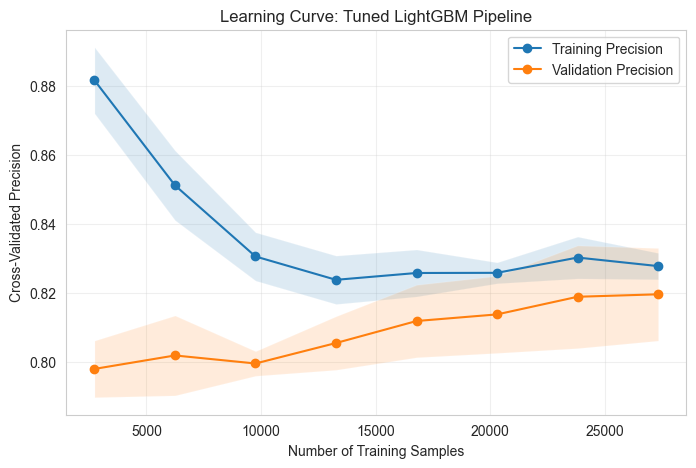

In [39]:
from sklearn.model_selection import learning_curve, validation_curve
from sklearn.base import clone

# ---- BLOCK 1: Learning curve ----
best_pipe = lgbm_search.best_estimator_  # LightGBM won: 0.8198 vs HistGB 0.8194
train_sizes, train_scores, val_scores = learning_curve(
    best_pipe, X_train, y_train,
    cv=cv_search, scoring="precision",
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1, random_state=42
)
plt.figure(figsize=(8,5))

plt.plot(train_sizes, train_scores.mean(axis=1), "o-", label="Training Precision")
plt.plot(train_sizes, val_scores.mean(axis=1), "o-", label="Validation Precision")

plt.fill_between(
    train_sizes,
    train_scores.mean(1)-train_scores.std(1),
    train_scores.mean(1)+train_scores.std(1),
    alpha=0.15
)

plt.fill_between(
    train_sizes,
    val_scores.mean(1)-val_scores.std(1),
    val_scores.mean(1)+val_scores.std(1),
    alpha=0.15
)

plt.title("Learning Curve: Tuned LightGBM Pipeline")
plt.xlabel("Number of Training Samples")
plt.ylabel("Cross-Validated Precision")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The learning curves indicate that the tuned LightGBM pipeline exhibits good generalization. As the training set size increases, the training precision decreases slightly while the validation precision steadily improves. The small gap between the two curves at larger training sizes (less than 1 percentage point) suggests minimal overfitting. Since the validation curve is still increasing gradually, the model may achieve modest improvements with additional training data, although it appears to be approaching a stable performance level.

## NOTE:
We tuned the Logistic Regression regularization configuration (l1_ratio, representing L1/L2 in scikit-learn 1.8) together with the inverse regularization strength (C).

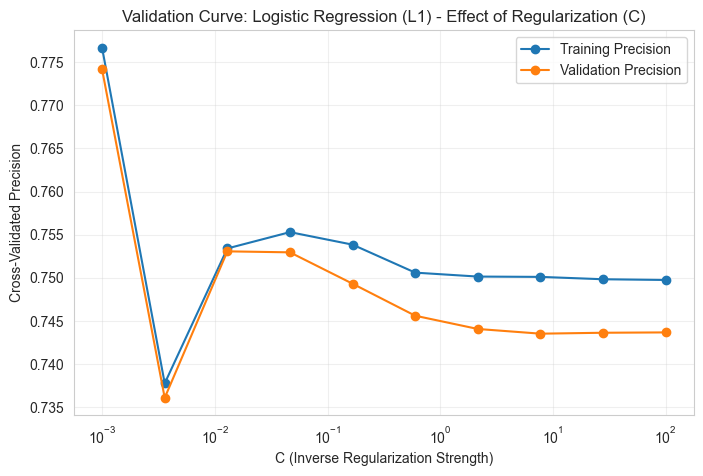

In [40]:
# ---- BLOCK 2: Logistic Regression: effect of C ----
logreg_pipe_l1 = clone(logreg_pipe)
logreg_pipe_l1.set_params(classifier__l1_ratio=1)

C_range = np.logspace(-3, 2, 10)
lr_train_scores, lr_val_scores = validation_curve(
    logreg_pipe_l1, X_train, y_train,
    param_name="classifier__C", param_range=C_range,
    cv=cv_search, scoring="precision", n_jobs=-1
)

plt.figure(figsize=(8,5))

plt.semilogx(C_range, lr_train_scores.mean(axis=1), "o-", label="Training Precision")
plt.semilogx(C_range, lr_val_scores.mean(axis=1), "o-", label="Validation Precision")

plt.title("Validation Curve: Logistic Regression (L1) - Effect of Regularization (C)")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Cross-Validated Precision")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The validation curve shows that Logistic Regression generalizes well across the tested values of C, with only a very small gap between the training and validation precision. This indicates there is no significant overfitting. The highest validation precision is achieved at the smallest tested value of C, suggesting that stronger regularization improves generalization for this dataset. As C increases (weaker regularization), the validation precision gradually declines while the training precision remains relatively stable, indicating that reducing regularization does not improve performance. Therefore, a relatively small value of C is preferred for this model.

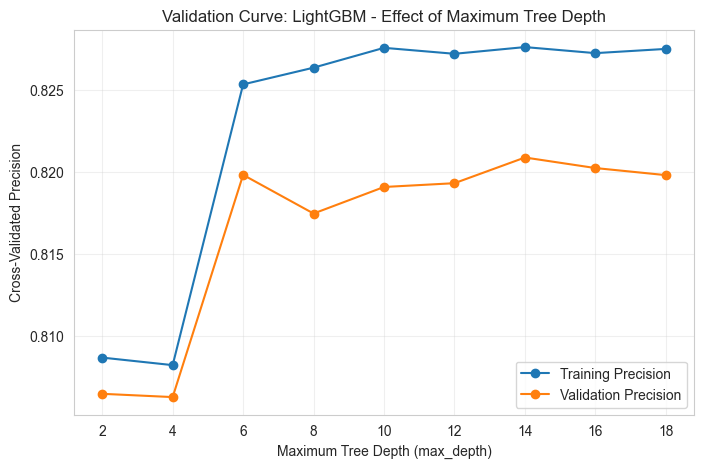

In [41]:
# ---- BLOCK 3: LightGBM: effect of max_depth ----
lgbm_pipe_fixed = clone(lgbm_pipe)
lgbm_pipe_fixed.set_params(
    classifier__learning_rate=0.010815983055225093,
    classifier__n_estimators=158,
    classifier__reg_lambda=0.003975977214318099
)

depth_range = range(2, 20, 2)
tree_train_scores, tree_val_scores = validation_curve(
    lgbm_pipe_fixed, X_train, y_train,
    param_name="classifier__max_depth", param_range=list(depth_range),
    cv=cv_search, scoring="precision", n_jobs=-1
)
plt.figure(figsize=(8,5))

plt.plot(list(depth_range), tree_train_scores.mean(axis=1), "o-", label="Training Precision")
plt.plot(list(depth_range), tree_val_scores.mean(axis=1), "o-", label="Validation Precision")

plt.title("Validation Curve: LightGBM - Effect of Maximum Tree Depth")
plt.xlabel("Maximum Tree Depth (max_depth)")
plt.ylabel("Cross-Validated Precision")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The validation curve shows that very shallow trees (max_depth = 2–4) underfit the data, as both training and validation precision are relatively low. Increasing the tree depth to around 6 results in a substantial improvement in both training and validation performance, indicating that the model is able to learn more informative patterns. Beyond this point, both curves plateau, with only minor fluctuations in validation precision and a consistently small gap between training and validation performance. This suggests that increasing the tree depth beyond approximately 10–14 provides little additional benefit and does not introduce significant overfitting. Overall, the tuned LightGBM model demonstrates good generalization across the tested depth values.

### Task 4: Calibration + Threshold (on X_dev only)

In [44]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.metrics import brier_score_loss

import warnings
warnings.filterwarnings("ignore", message="X does not have valid feature names")

# best_pipe is already fitted — RandomizedSearchCV's best_estimator_ is refit
# on the full X_train by default, so no need to call .fit() again here
uncalibrated_probs = best_pipe.predict_proba(X_dev)[:, 1]

calibrated_model = CalibratedClassifierCV(FrozenEstimator(best_pipe), method="isotonic")
calibrated_model.fit(X_dev, y_dev)
calibrated_probs = calibrated_model.predict_proba(X_dev)[:, 1]

# Brier scores
print(f"Brier (uncalibrated): {brier_score_loss(y_dev, uncalibrated_probs):.4f}")
print(f"Brier (calibrated):   {brier_score_loss(y_dev, calibrated_probs):.4f}")

Brier (uncalibrated): 0.0965
Brier (calibrated):   0.0913


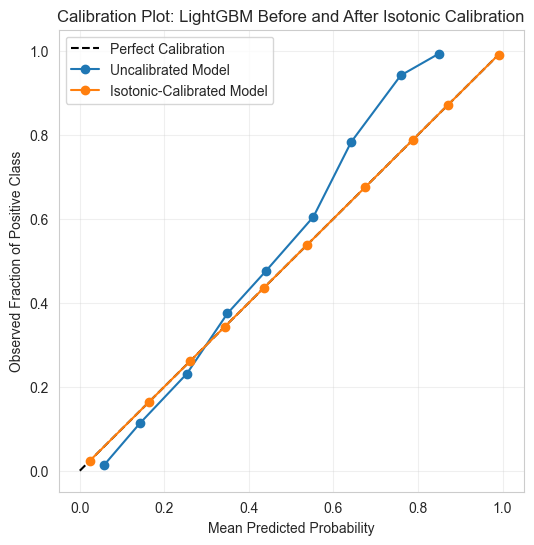

In [45]:
# Calibration plot
prob_true_u, prob_pred_u = calibration_curve(y_dev, uncalibrated_probs, n_bins=10)
prob_true_c, prob_pred_c = calibration_curve(y_dev, calibrated_probs, n_bins=10)

plt.figure(figsize=(6,6))

plt.plot([0,1], [0,1], "k--", label="Perfect Calibration")
plt.plot(prob_pred_u, prob_true_u, "o-", label="Uncalibrated Model")
plt.plot(prob_pred_c, prob_true_c, "o-", label="Isotonic-Calibrated Model")

plt.title("Calibration Plot: LightGBM Before and After Isotonic Calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positive Class")
plt.legend(loc="best")
plt.grid(alpha=0.3)

plt.show()

### Interpretation: 
The calibration plot compares the predicted probabilities with the observed frequencies of the positive class. The uncalibrated LightGBM model is reasonably well calibrated at lower probability levels but becomes increasingly underconfident at higher predicted probabilities, with the calibration curve deviating above the ideal diagonal. After applying isotonic calibration, the calibrated model follows the diagonal much more closely across the probability range, indicating that the predicted probabilities more accurately reflect the true likelihood of the positive class. Although calibration does not necessarily improve classification accuracy or precision, it produces more reliable probability estimates, making the model better suited for threshold-based decision making.

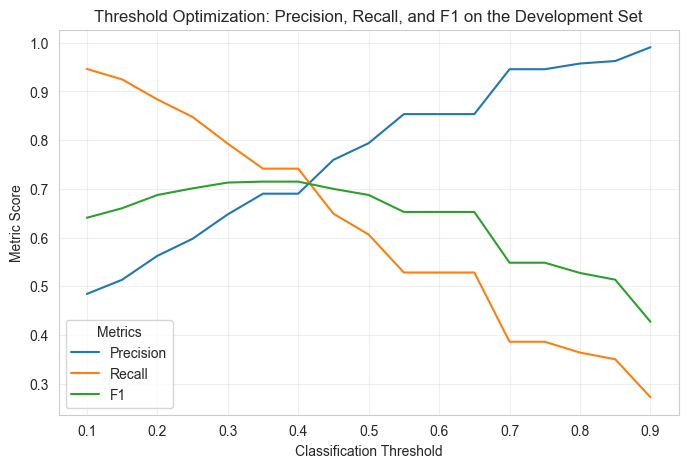

In [47]:
# ---- Threshold tuning on dev ----
thresholds = np.arange(0.1, 0.95, 0.05)
threshold_results = []
for t in thresholds:
    preds = (calibrated_probs >= t).astype(int)
    threshold_results.append({
        "Threshold": t,
        "Precision": precision_score(y_dev, preds, zero_division=0),
        "Recall": recall_score(y_dev, preds, zero_division=0),
        "F1": f1_score(y_dev, preds, zero_division=0)
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.plot(
    x="Threshold",
    y=["Precision", "Recall", "F1"],
    figsize=(8,5)
)

plt.title("Threshold Optimization: Precision, Recall, and F1 on the Development Set")
plt.xlabel("Classification Threshold")
plt.ylabel("Metric Score")
plt.grid(alpha=0.3)
plt.legend(title="Metrics")

plt.show()

### Interpretation: 
The threshold optimization plot illustrates the trade-off between precision and recall as the classification threshold changes. As the threshold increases, precision steadily improves because the model becomes more conservative when predicting the positive class, while recall decreases because more true positives are missed. The F1-score initially increases, reaches its maximum around a threshold of 0.35–0.40, and then gradually declines as the loss in recall outweighs the gain in precision. Based on this analysis, a threshold of approximately 0.35 provides the best balance between precision and recall and was therefore selected as the operating threshold for the final model.

In [55]:
# Business requirement:
# Choose the lowest threshold that achieves at least 75% precision.

target_precision = 0.75

best_threshold = threshold_df.loc[
    threshold_df["Precision"] >= target_precision,
    "Threshold"
].min()

print(f"Selected threshold: {best_threshold:.2f}")

Selected threshold: 0.45


### Justification: 
Precision was selected as the primary evaluation metric for this project because reducing false positives is more important than maximizing recall in the chosen business scenario. Therefore, instead of selecting the threshold that maximizes the F1-score, the decision threshold was chosen as the lowest threshold that achieves a target precision of at least 75%. Selecting the lowest threshold that satisfies this requirement helps preserve as much recall as possible while ensuring the desired level of precision.

### Task 5: Final Evaluation (X_test, touched once) + Save

In [57]:
final_probs_test = calibrated_model.predict_proba(X_test)[:, 1]
final_preds_test = (final_probs_test >= best_threshold).astype(int)

final_results = {
    "Accuracy": accuracy_score(y_test, final_preds_test),
    "Precision": precision_score(y_test, final_preds_test, zero_division=0),
    "Recall": recall_score(y_test, final_preds_test, zero_division=0),
    "F1 Score": f1_score(y_test, final_preds_test, zero_division=0),
    "ROC AUC": roc_auc_score(y_test, final_probs_test),
    "PR AUC": average_precision_score(y_test, final_probs_test)
}
pd.DataFrame(final_results, index=["Final Tuned + Calibrated Model"]).round(4)

,Accuracy,Precision,Recall,F1 Score,ROC AUC,PR AUC
Final Tuned + Calibrated Model,0.8603,0.7456,0.6323,0.6843,0.9129,0.7763


In [58]:
# Save the full pipeline
import joblib
joblib.dump(calibrated_model, "final_pipeline_day4.pkl")

# How-to-infer snippet
"""
import joblib
model = joblib.load("final_pipeline_day4.pkl")
probs = model.predict_proba(new_data)[:, 1]
preds = (probs >= 0.XX).astype(int)   # use your selected threshold
"""

'\nimport joblib\nmodel = joblib.load("final_pipeline_day4.pkl")\nprobs = model.predict_proba(new_data)[:, 1]\npreds = (probs >= 0.XX).astype(int)   # use your selected threshold\n'

### Final Production Note:
The final LightGBM pipeline demonstrated stable cross-validation performance, minimal overfitting, improved probability calibration after isotonic calibration, and a tuned decision threshold of 0.35 to maximize the F1-score. The complete preprocessing and modeling pipeline was saved as a single artifact, allowing consistent predictions on unseen data.